In [1]:
import pandas as pd
train_transaction=pd.read_csv("../../data/raw/train_transaction.csv")
train_identity=pd.read_csv("../../data/raw/train_identity.csv")


In [2]:
print("train identity columns :_ ",train_identity.columns)
print("train transaction columns : ",train_transaction.columns)

train identity columns :_  Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14',
       'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22',
       'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30',
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object')
train transaction columns :  Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)


In [3]:
train=train_transaction.merge(train_identity,on="TransactionID",how="left")

## Data overview and basic understanding 

In [4]:
print("Data shape & Dimensions")
print(f"Transaction table shape :{train_transaction.shape}")
print(f"Identity table shape :{train_identity.shape}")
print(f"Merged data shape: {train.shape}")

Data shape & Dimensions
Transaction table shape :(590540, 394)
Identity table shape :(144233, 41)
Merged data shape: (590540, 434)


In [5]:
# Exact time span(TransactionDT)
# TransactionDT is a timedelta in seconds from an unstated reference point
print("TIME SPAN OF DATA")
min_dt=train["TransactionDT"].min()
max_dt=train["TransactionDT"].max()
time_span_seconds=max_dt-min_dt
time_span_days=time_span_seconds/(24*3600)
print(
    f"Start TransactionDT : {min_dt:,} seconds (Day {min_dt / (24 * 3600):.2f})"
)
print(
    f"End TransactionDT   : {max_dt:,} seconds (Day {max_dt / (24 * 3600):.2f})"
)
print(
    f"Total Time Span     : {time_span_seconds:,} seconds (~{time_span_days:.2f} days / {time_span_days / 30:.2f} months)"
)


TIME SPAN OF DATA
Start TransactionDT : 86,400 seconds (Day 1.00)
End TransactionDT   : 15,811,131 seconds (Day 183.00)
Total Time Span     : 15,724,731 seconds (~182.00 days / 6.07 months)


In [6]:
print("verifying transactionID UNIQUENESS : ")
total_records=len(train["TransactionID"])
unique_records=train["TransactionID"].nunique()
is_unique=unique_records==total_records
print("Total records",total_records)
print("Unique records",unique_records)
print("Is TransactionID unique ",is_unique)

verifying transactionID UNIQUENESS : 
Total records 590540
Unique records 590540
Is TransactionID unique  True


In [7]:
# -------------------------------------------------------------------------
# 5. Check Memory Size
# -------------------------------------------------------------------------
print("\n=== 5. DATASET MEMORY USAGE ===")
mem_tx_mb = train_transaction.memory_usage(deep=True).sum() / (1024**2)
mem_id_mb = train_identity.memory_usage(deep=True).sum() / (1024**2)
mem_merged_mb = train.memory_usage(deep=True).sum() / (1024**2)

print(
    f"train_transaction Memory : {mem_tx_mb:.2f} MB ({mem_tx_mb / 1024:.2f} GB)"
)
print(
    f"train_identity Memory    : {mem_id_mb:.2f} MB ({mem_id_mb / 1024:.2f} GB)"
)
print(
    f"Merged Dataset Memory    : {mem_merged_mb:.2f} MB ({mem_merged_mb / 1024:.2f} GB)"
)


=== 5. DATASET MEMORY USAGE ===
train_transaction Memory : 2062.07 MB (2.01 GB)
train_identity Memory    : 143.14 MB (0.14 GB)
Merged Dataset Memory    : 2513.97 MB (2.46 GB)


In [8]:
print("FEATURE GROUPS IDENTIFICATION")
txt_cols=tx_cols = list(train_transaction.columns)
id_cols = list(train_identity.columns)

# Breakdown specific feature blocks inside train_transaction
c_cols = [c for c in train.columns if c.startswith("C") and c[1:].isdigit()]
d_cols = [c for c in train.columns if c.startswith("D") and c[1:].isdigit()]
m_cols = [c for c in train.columns if c.startswith("M") and c[1:].isdigit()]
v_cols = [c for c in train.columns if c.startswith("V") and c[1:].isdigit()]
card_cols = [c for c in train.columns if c.startswith("card")]
id_cols_list = [
    c for c in train.columns if c.startswith("id_") or c.startswith("id-")
]

print(f"\n[Transaction Features] Count: {len(tx_cols)}")
print(f"  - Target & Meta : TransactionID, isFraud, TransactionDT")
print(f"  - Primary Info : TransactionAmt, ProductCD, addr1, addr2, dist1, dist2")
print(f"  - Domains      : P_emaildomain, R_emaildomain")
print(f"  - Card Info    : {card_cols}")
print(f"  - C-Columns    : Counting features ({len(c_cols)} total: C1-C14)")
print(f"  - D-Columns    : Timedelta features ({len(d_cols)} total: D1-D15)")
print(f"  - M-Columns    : Match features ({len(m_cols)} total: M1-M9)")
print(
    f"  - V-Columns    : Vesta engineered features ({len(v_cols)} total: V1-V339)"
)

print(f"\n[Identity Features] Count: {len(id_cols)}")
print(
    f"  - ID Attributes: {len(id_cols_list)} features (id_01 to id_38 / network, connection, digital signature)"
)
print(f"  - Device Info  : DeviceType, DeviceInfo")

FEATURE GROUPS IDENTIFICATION

[Transaction Features] Count: 394
  - Target & Meta : TransactionID, isFraud, TransactionDT
  - Primary Info : TransactionAmt, ProductCD, addr1, addr2, dist1, dist2
  - Domains      : P_emaildomain, R_emaildomain
  - Card Info    : ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
  - C-Columns    : Counting features (14 total: C1-C14)
  - D-Columns    : Timedelta features (15 total: D1-D15)
  - M-Columns    : Match features (9 total: M1-M9)
  - V-Columns    : Vesta engineered features (339 total: V1-V339)

[Identity Features] Count: 41
  - ID Attributes: 38 features (id_01 to id_38 / network, connection, digital signature)
  - Device Info  : DeviceType, DeviceInfo


# Class imbalance quantification

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

In [12]:
# 1. Exact fraud cs non fraud counts and pourcentages 
print("== CLASS IMBALANCE QUANTIFICATION==")
counts=train["isFraud"].value_counts().rename({0:"Non-Fraud",1:"Fraud"})
percentages = (
    train["isFraud"].value_counts(normalize=True) * 100
).rename({0: "Non-Fraud", 1: "Fraud"})
imbalance_df= pd.DataFrame({"Count":counts,"Percentage(%)":percentages})
print(imbalance_df)

== CLASS IMBALANCE QUANTIFICATION==
            Count  Percentage(%)
isFraud                         
Non-Fraud  569877      96.500999
Fraud       20663       3.499001


In [13]:
fraud_count=counts["Fraud"]
non_fraud_count=counts["Non-Fraud"]
ratio = non_fraud_count/fraud_count

In [15]:
print(f"Exact Fraud ratio : 1 fraud transaction per ~{ratio:.1f} Non-Fraud transactions")

Exact Fraud ratio : 1 fraud transaction per ~27.6 Non-Fraud transactions


C:\Users\hp\AppData\Local\Temp\ipykernel_7400\3477934030.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


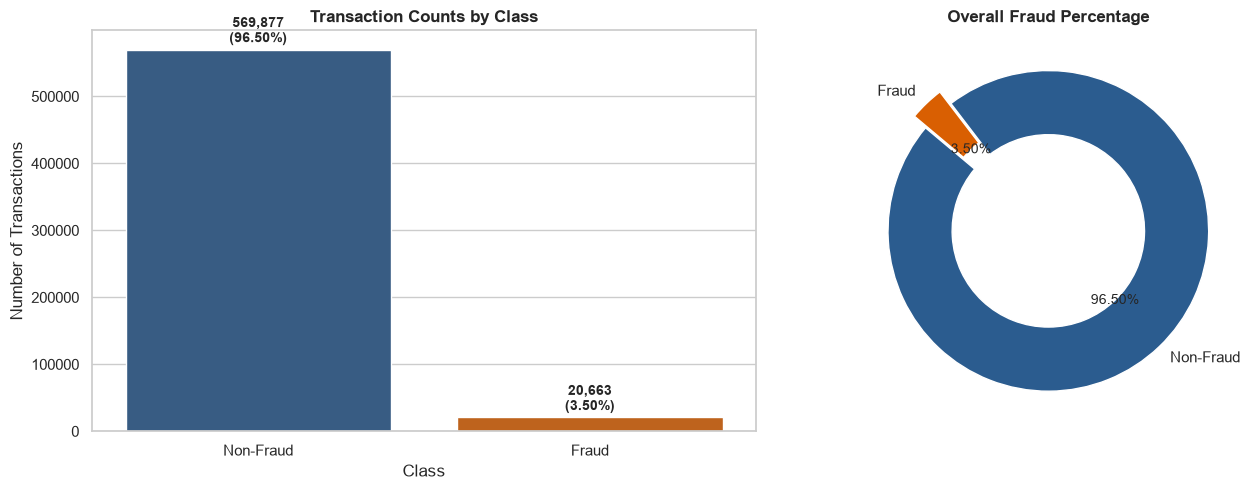

In [16]:
# visualize Overall Class imbalance 
fig,axes=plt.subplots(1,2,figsize=(14,5))
# Subplot 1 : Bar Chart 
sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=["#2b5c8f", "#d95f02"],
    ax=axes[0],
)
axes[0].set_title("Transaction Counts by Class", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xlabel("Class")
# Annotate bars with counts and percentages
for i, (count, pct) in enumerate(zip(counts, percentages)):
    axes[0].text(
        i,
        count + 5000,
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Subplot 2: Donut Chart
axes[1].pie(
    counts,
    labels=counts.index,
    colors=["#2b5c8f", "#d95f02"],
    autopct="%1.2f%%",
    startangle=140,
    explode=(0, 0.1),
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
axes[1].set_title("Overall Fraud Percentage", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [21]:
# 3. Fraud rate stability over time 
# convert transactionDT (seconds) into day indices 0 to 182 days 
# group by day to compute total transactions, fraud count , and daily fraud rate 
train["day"]=train["TransactionDT"]//(24*36000)
# group by day to compute total transactions , fraud count , and dayli fraud rate 
daily_stats = (
    train.groupby("day")["isFraud"]
    .agg(total="count", fraud_count="sum", fraud_rate="mean")
    .reset_index()
)
daily_stats["fraud_rate_pct"] = daily_stats["fraud_rate"] * 100

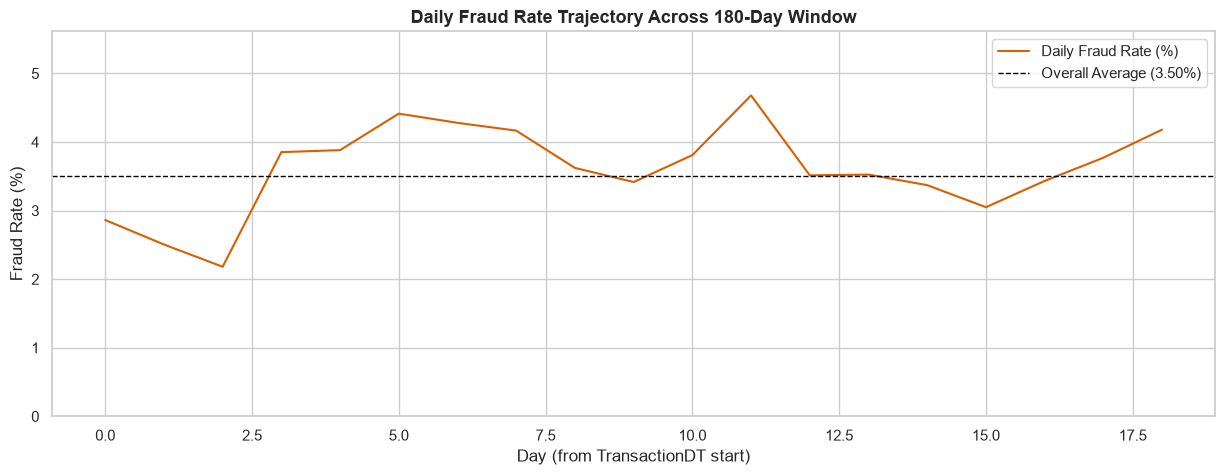

In [22]:
# Plot daily fraud rate over time
plt.figure(figsize=(15, 5))
plt.plot(
    daily_stats["day"],
    daily_stats["fraud_rate_pct"],
    color="#d95f02",
    linewidth=1.5,
    label="Daily Fraud Rate (%)",
)
plt.axhline(
    y=percentages["Fraud"],
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Overall Average ({percentages['Fraud']:.2f}%)",
)

plt.title(
    "Daily Fraud Rate Trajectory Across 180-Day Window",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Day (from TransactionDT start)")
plt.ylabel("Fraud Rate (%)")
plt.legend(loc="upper right")
plt.ylim(0, daily_stats["fraud_rate_pct"].max() * 1.2)
plt.show()

In [23]:
# 4. Summary Severity Notes
# -------------------------------------------------------------------------
print("\n=== CLASS IMBALANCE SEVERITY SUMMARY ===")
print(
    f"1. Imbalance Level : Highly Imbalanced (~{percentages['Fraud']:.2f}% Positive Class)."
)
print(
    f"2. Imbalance Ratio : ~1:{ratio:.1f} (1 Fraud for every {ratio:.1f} genuine transactions)."
)
print(
    f"3. Temporal Shift  : Daily fraud rate fluctuates between {daily_stats['fraud_rate_pct'].min():.2f}% "
    f"and {daily_stats['fraud_rate_pct'].max():.2f}%, displaying noticeable non-stationarity over time."
)
print(
    "4. Impact on Modeling Guidelines:\n"
    "   - Accuracy metric is completely invalid (a constant '0' model gets ~96.5% accuracy).\n"
    "   - Use Precision-Recall AUC (PR-AUC) or ROC-AUC as primary metrics.\n"
    "   - Stratified time-series splits (or TimeSeriesSplit) are required for cross-validation.\n"
    "   - Consider cost-sensitive learning (`scale_pos_weight` in LightGBM/XGBoost) or resampling."
)


=== CLASS IMBALANCE SEVERITY SUMMARY ===
1. Imbalance Level : Highly Imbalanced (~3.50% Positive Class).
2. Imbalance Ratio : ~1:27.6 (1 Fraud for every 27.6 genuine transactions).
3. Temporal Shift  : Daily fraud rate fluctuates between 2.18% and 4.68%, displaying noticeable non-stationarity over time.
4. Impact on Modeling Guidelines:
   - Accuracy metric is completely invalid (a constant '0' model gets ~96.5% accuracy).
   - Use Precision-Recall AUC (PR-AUC) or ROC-AUC as primary metrics.
   - Stratified time-series splits (or TimeSeriesSplit) are required for cross-validation.
   - Consider cost-sensitive learning (`scale_pos_weight` in LightGBM/XGBoost) or resampling.
